# ❤️ Heart Disease Prediction using Machine Learning

This project aims to predict the presence of heart disease using multiple supervised machine learning algorithms.

The notebook covers the complete machine learning workflow, including:

- Data Exploration (EDA)
- Data Preprocessing
- Model Comparison
- Hyperparameter Optimization
- Threshold Optimization
- Model Evaluation
- Explainable AI (SHAP)

The objective is to identify the best-performing model while minimizing false negatives, which is particularly important in medical diagnosis.

In [1]:
import os
import pickle

from sklearn.svm import SVC , LinearSVC
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.calibration import CalibratedClassifierCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, train_test_split , StratifiedKFold , cross_val_score ,cross_val_predict

# Dataset

**Dataset:** Heart Disease Dataset

- Task: Binary Classification
- Target:
  - **0 → No Heart Disease**
  - **1 → Heart Disease**
- Missing Values: None
- Features: Clinical and laboratory measurements collected from patients.

In [2]:
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


# Exploratory Data Analysis (EDA)

Explore the dataset to better understand feature distributions, class balance, and relationships between variables.

This section includes:

- Dataset information
- Summary statistics
- Class distribution
- Correlation analysis
- Data visualization

In [3]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [4]:
df["oldpeak"] =df.oldpeak.astype(int)
df.dtypes

age         int64
sex         int64
cp          int64
trestbps    int64
chol        int64
fbs         int64
restecg     int64
thalach     int64
exang       int64
oldpeak     int64
slope       int64
ca          int64
thal        int64
target      int64
dtype: object

In [5]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       303 non-null    int64
 1   sex       303 non-null    int64
 2   cp        303 non-null    int64
 3   trestbps  303 non-null    int64
 4   chol      303 non-null    int64
 5   fbs       303 non-null    int64
 6   restecg   303 non-null    int64
 7   thalach   303 non-null    int64
 8   exang     303 non-null    int64
 9   oldpeak   303 non-null    int64
 10  slope     303 non-null    int64
 11  ca        303 non-null    int64
 12  thal      303 non-null    int64
 13  target    303 non-null    int64
dtypes: int64(14)
memory usage: 33.3 KB


In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

## Correlation Matrix

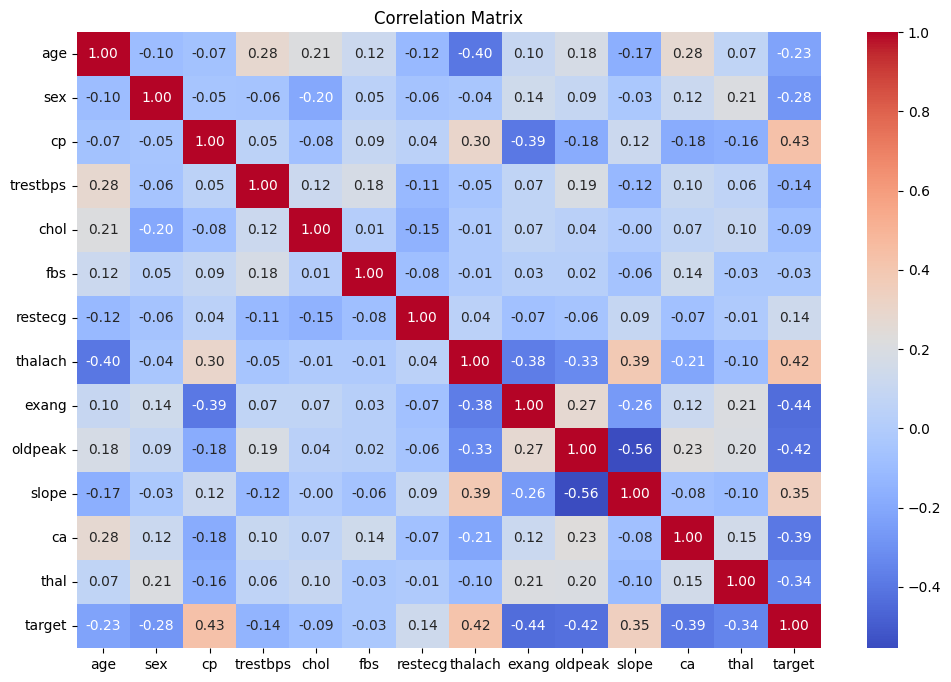

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [9]:
#np.random.seed(42)
X = df.drop("target",axis=1)
y = df["target"].values


# Data Preprocessing

Prepare the dataset before training machine learning models.

This stage includes:

- Feature encoding
- Train/Test Split
- Feature scaling (performed inside the pipeline to prevent data leakage)

In [10]:

X = X.copy()

df = pd.DataFrame(
    X,
    columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
             'exang', 'oldpeak', 'slope', 'ca', 'thal']
)

#OneHotEncoder
ct = ColumnTransformer(
    transformers=[
        (
            'One_Hot_Encoder',
            OneHotEncoder(sparse_output=False),
            ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
        )
    ],
    remainder='passthrough'
)

X = ct.fit_transform(df)

print(X[:5])
print("Shape of X:", X.shape)


feature_names = ct.get_feature_names_out().tolist()

print("\nFeature Names after One-Hot Encoding:")
print(feature_names)

[[  0.   1.   0.   0.   0.   1.   0.   1.   1.   0.   0.   1.   0.   1.
    0.   0.   1.   0.   0.   0.   0.   0.   1.   0.   0.  63. 145. 233.
  150.   2.]
 [  0.   1.   0.   0.   1.   0.   1.   0.   0.   1.   0.   1.   0.   1.
    0.   0.   1.   0.   0.   0.   0.   0.   0.   1.   0.  37. 130. 250.
  187.   3.]
 [  1.   0.   0.   1.   0.   0.   1.   0.   1.   0.   0.   1.   0.   0.
    0.   1.   1.   0.   0.   0.   0.   0.   0.   1.   0.  41. 130. 204.
  172.   1.]
 [  0.   1.   0.   1.   0.   0.   1.   0.   0.   1.   0.   1.   0.   0.
    0.   1.   1.   0.   0.   0.   0.   0.   0.   1.   0.  56. 120. 236.
  178.   0.]
 [  1.   0.   1.   0.   0.   0.   1.   0.   0.   1.   0.   0.   1.   0.
    0.   1.   1.   0.   0.   0.   0.   0.   0.   1.   0.  57. 120. 354.
  163.   0.]]
Shape of X: (303, 30)

Feature Names after One-Hot Encoding:
['One_Hot_Encoder__sex_0', 'One_Hot_Encoder__sex_1', 'One_Hot_Encoder__cp_0', 'One_Hot_Encoder__cp_1', 'One_Hot_Encoder__cp_2', 'One_Hot_Encoder__cp_3', 

In [11]:
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

# PCA Visualization

Principal Component Analysis (PCA) is used **only for visualization purposes** to project the dataset into a two-dimensional space.

**Note:** PCA is **not** used during model training and does not affect model performance.

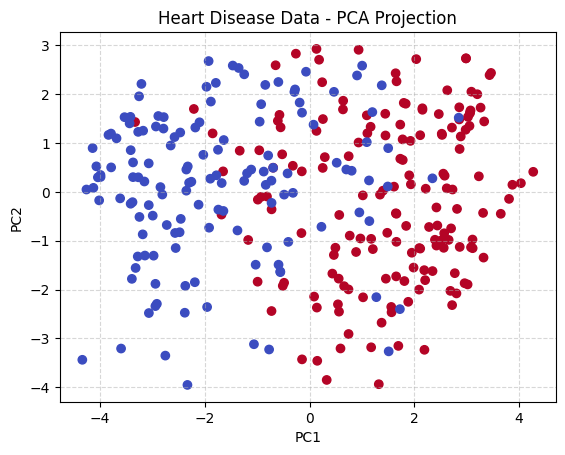

Explained variance ratio: [0.16568497 0.08432628]
Total variance captured: 25.00%


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Heart Disease Data - PCA Projection')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_)*100:.2f}%")


# Baseline Model Comparison

Train and compare multiple machine learning algorithms using identical evaluation procedures.

The following models are evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

In [24]:
models= {"KNN":KNeighborsClassifier(n_neighbors=70 , algorithm="brute" ,metric="euclidean" ,n_jobs=-1),
         "Logistic Regression":LogisticRegression(C=0.01 , l1_ratio=0 , solver='lbfgs' ,max_iter=1000) ,
         "Decision Tree":DecisionTreeClassifier(max_depth=3 , min_samples_split=3),
         "Random Forest":RandomForestClassifier(max_depth=3 , min_samples_split=3 , n_estimators=100 , max_features=5) ,
         "SVM(SVC , kernel=linear)":SVC( kernel="linear" , C=0.1 ),
         "SVM(LinearSVC)":LinearSVC(C=0.1, penalty="l2" , loss="squared_hinge" ),
         "SVM(SVC , kernel=rbf)":SVC( gamma=0.01,kernel="rbf", C=0.1 )}

for name,model in models.items():
    Score = cross_val_score(model,X_scaled, y,cv=5,scoring="f1").mean()
    print(f"{name}  : {Score}")
print("scoring : f1-score")

KNN  : 0.8633447307097588
Logistic Regression  : 0.8599237382335975
Decision Tree  : 0.7915136548978781
Random Forest  : 0.8595263371272411
SVM(SVC , kernel=linear)  : 0.8503277786376378
SVM(LinearSVC)  : 0.8570593206268937
SVM(SVC , kernel=rbf)  : 0.8629249436009999
scoring : f1-score


# Model Selection

Several supervised machine learning algorithms were evaluated using the **F1-Score** as the primary evaluation metric.

| Model | F1-Score |
|--------|---------:|
| K-Nearest Neighbors (KNN) | 0.8633 |
| Logistic Regression | 0.8599 |
| Random Forest | 0.8595 |
| SVM (RBF Kernel) | 0.8629 |
| SVM (LinearSVC) | 0.8571 |
| SVM (Linear Kernel) | 0.8503 |
| Decision Tree | 0.7915 |

Although **KNN** achieved the highest F1-Score, the performance difference compared with **SVM using the RBF kernel** was very small.

The **Support Vector Machine (SVM)** was selected as the final model because:

- It achieved competitive predictive performance.
- It is effective for high-dimensional feature spaces.
- It provides strong generalization through margin maximization.
- The RBF kernel can model both linear and non-linear decision boundaries.
- It is a well-established algorithm for binary classification problems in medical applications.

For these reasons, the remaining experiments, including hyperparameter optimization, threshold tuning, and explainability, were performed using the **SVM with the RBF kernel**.

## Hyperparameter Optimization

Optimize model performance using GridSearchCV combined with Repeated Stratified Cross Validation.

The best hyperparameter combination is selected based on the F1_score .

## Model Stability Analysis

Evaluate model performance across multiple random train/test splits to assess robustness and reduce dependency on a single random state.

## Saving Computation Results

Grid Search can be computationally expensive.

To avoid repeating the optimization process, the best search results are stored and reused when available.

In [14]:
params = [

    # ==================================================
    # Linear Kernel
    # ==================================================

    {
        "model__kernel": ["linear"],

        "model__C": [
            0.01,
            0.1,
            1,
            10
        ],

        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3}
        ]
    },

    # ==================================================
    # RBF Kernel
    # ==================================================

    {
        "model__kernel": ["rbf"],

        "model__C": [
            0.01,
            0.1,
            1,
            10
        ],

        "model__gamma": [
            "scale",
            "auto",
            0.001,
            0.01,
            0.1
        ],

        "model__class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3}
        ]
    }

]

In [15]:


# --------------------------------------------------
# Random States
# --------------------------------------------------

random_states = [1,5,55,6,16,77,40,23,10,120]

# --------------------------------------------------
# Cache File
# --------------------------------------------------

cache_file = "svm_grid_search_stability.pkl"

if os.path.exists(cache_file):

    with open(cache_file, "rb") as f:
        data = pickle.load(f)

    df_results = data["df_results"]
    summary = data["summary"]

    print("Loaded results from cache.")

else:

    # --------------------------------------------------
    # Run GridSearch
    # --------------------------------------------------

    results = []
    all_cv_results = []

    for rs in random_states:

        print("=" * 70)
        print(f"Train/Test Split Random State : {rs}")
        print("=" * 70)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.20,
            stratify=y,
            random_state=rs
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True))
        ])

        cv = RepeatedStratifiedKFold(
            n_splits=5,
            n_repeats=10,
            random_state=42
        )

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            scoring="f1",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
            return_train_score=False
        )

        grid.fit(X_train, y_train)

        results.append({

            "split_random_state": rs,

            "best_score": grid.best_score_,

            "best_params": str(grid.best_params_),

            "kernel": grid.best_params_["model__kernel"],

            "C": grid.best_params_["model__C"],

            "gamma": grid.best_params_.get(
                "model__gamma",
                None
            ),

            "class_weight": str(
                grid.best_params_["model__class_weight"]
            )

        })

        cv_results = pd.DataFrame(
            grid.cv_results_
        )

        cv_results["split_random_state"] = rs

        all_cv_results.append(
            cv_results
        )

    # --------------------------------------------------
    # Summary
    # --------------------------------------------------

    df_results = pd.DataFrame(
        results
    )

    all_cv_results = pd.concat(
        all_cv_results,
        ignore_index=True
    )

    all_cv_results["param_model__class_weight"] = (
        all_cv_results["param_model__class_weight"]
        .astype(str)
    )

    summary = (

    all_cv_results.groupby(

        [
            "param_model__kernel",
            "param_model__C",
            "param_model__gamma",
            "param_model__class_weight"
        ],

        dropna=False

    )

    .agg(

        Mean_F1=("mean_test_score", "mean"),
        Std_F1=("mean_test_score", "std"),
        Max_F1=("mean_test_score", "max"),
        Min_F1=("mean_test_score", "min"),
        Count=("mean_test_score", "count")

    )

    .sort_values(

        by="Mean_F1",
        ascending=False

    )

)
    # --------------------------------------------------
    # Save Cache
    # --------------------------------------------------

    with open(
        cache_file,
        "wb"
    ) as f:

        pickle.dump(

            {

                "df_results": df_results,

                "summary": summary

            },

            f

        )

    print(
        "Results saved to cache."
    )

# --------------------------------------------------
# Print Results
# --------------------------------------------------

print("\nResults\n")

print(df_results)

print("\nAverage Best CV Score\n")

print(
    df_results["best_score"].mean()
)

print("\nBest Parameter Frequency\n")

print(
    df_results["best_params"].value_counts()
)

print("\nKernel Frequency\n")

print(
    df_results["kernel"].value_counts()
)

print("\nC Frequency\n")

print(
    df_results["C"].value_counts()
)

print("\nGamma Frequency\n")

print(
    df_results["gamma"].value_counts(dropna=False)
)

print("\nClass Weight Frequency\n")

print(
    df_results["class_weight"].value_counts()
)

print("\n")

print("=" * 100)
summary.head(20)

Loaded results from cache.

Results

   split_random_state  best_score  \
0                   1    0.878178   
1                   5    0.866227   
2                  55    0.870462   
3                   6    0.879955   
4                  16    0.854789   
5                  77    0.868253   
6                  40    0.868489   
7                  23    0.856502   
8                  10    0.860751   
9                 120    0.870057   

                                         best_params  kernel     C  gamma  \
0  {'model__C': 0.1, 'model__class_weight': None,...     rbf  0.10  0.010   
1  {'model__C': 0.1, 'model__class_weight': None,...     rbf  0.10  0.010   
2  {'model__C': 0.01, 'model__class_weight': None...  linear  0.01    NaN   
3  {'model__C': 1, 'model__class_weight': None, '...     rbf  1.00  0.001   
4  {'model__C': 1, 'model__class_weight': None, '...     rbf  1.00  0.001   
5  {'model__C': 1, 'model__class_weight': None, '...     rbf  1.00  0.001   
6  {'model__C': 

Mean_F1  \
param_model__kernel param_model__C param_model__gamma param_model__class_weight             
rbf                 1.00           0.001              NaN                        0.865709   
                    0.10           0.01               NaN                        0.864394   
linear              0.01           NaN                NaN                        0.858807   
                                                      {0: 1, 1: 2}               0.858413   
rbf                 10.00          0.001              {0: 1, 1: 2}               0.857884   
linear              0.10           NaN                {0: 1, 1: 2}               0.855247   
rbf                 10.00          0.001              NaN                        0.855247   
                    1.00           0.001              balanced                   0.855079   
                                   0.01               {0: 1, 1: 2}               0.852458   
linear              1.00           NaN                {0: 1, 1: 2}               0.851940   
rbf                 1.00           0.01               NaN                        0.851479   
linear              10.00          NaN                {0: 1, 1: 2}               0.850752   
rbf                 0.10           scale              NaN                        0.850670   
                                   auto               NaN                        0.850516   
linear              0.01           NaN                balanced                   0.849306   
rbf                 10.00          0.001              balanced                   0.848175   
linear              0.10           NaN                {0: 1, 1: 3}               0.848033   
                                                      NaN                        0.847569   
                    10.00          NaN                {0: 1, 1: 3}               0.847286   
                    1.00           NaN                {0: 1, 1: 3}               0.847003   

                                                                                   Std_F1  \
param_model__kernel param_model__C param_model__gamma param_model__class_weight             
rbf                 1.00           0.001              NaN                        0.008415   
                    0.10           0.01               NaN                        0.007845   
linear              0.01           NaN                NaN                        0.008632   
                                                      {0: 1, 1: 2}               0.004502   
rbf                 10.00          0.001              {0: 1, 1: 2}               0.005567   
linear              0.10           NaN                {0: 1, 1: 2}               0.007114   
rbf                 10.00          0.001              NaN                        0.008367   
                    1.00           0.001              balanced                   0.009255   
                                   0.01               {0: 1, 1: 2}               0.005652   
linear              1.00           NaN                {0: 1, 1: 2}               0.008847   
rbf                 1.00           0.01               NaN                        0.011514   
linear              10.00          NaN                {0: 1, 1: 2}               0.008924   
rbf                 0.10           scale              NaN                        0.010285   
                                   auto               NaN                        0.010398   
linear              0.01           NaN                balanced                   0.011599   
rbf                 10.00          0.001              balanced                   0.010905   
linear              0.10           NaN                {0: 1, 1: 3}               0.007382   
                                                      NaN                        0.005823   
                    10.00          NaN                {0: 1, 1: 3}               0.008575   
                    1.00           NaN                {0: 1, 1: 3}               0

# Threshold Optimization

Instead of using the default classification threshold , different probability thresholds are evaluated.

A cost-based approach is used to minimize False Negatives while controlling False Positives, which is especially important for medical applications.

Processing Random State : 10
Processing Random State : 20
Processing Random State : 30
Processing Random State : 40
Processing Random State : 50
Processing Random State : 60
Processing Random State : 2
Processing Random State : 100
Processing Random State : 500
Processing Random State : 1000
Processing Random State : 27

Results Table (With Calibration)

    random_state  threshold  cost_test  FN_test  FP_test  Recall_test
0             10       0.35       26.0        3       11         0.94
1             20       0.19       20.0        0       20         1.00
2             30       0.24       24.0        2       14         0.96
3             40       0.21       24.0        2       14         0.96
4             50       0.29       25.0        2       15         0.96
5             60       0.31       26.0        2       16         0.96
6              2       0.32       31.0        4       11         0.92
7            100       0.20       18.0        0       18         1.00
8            

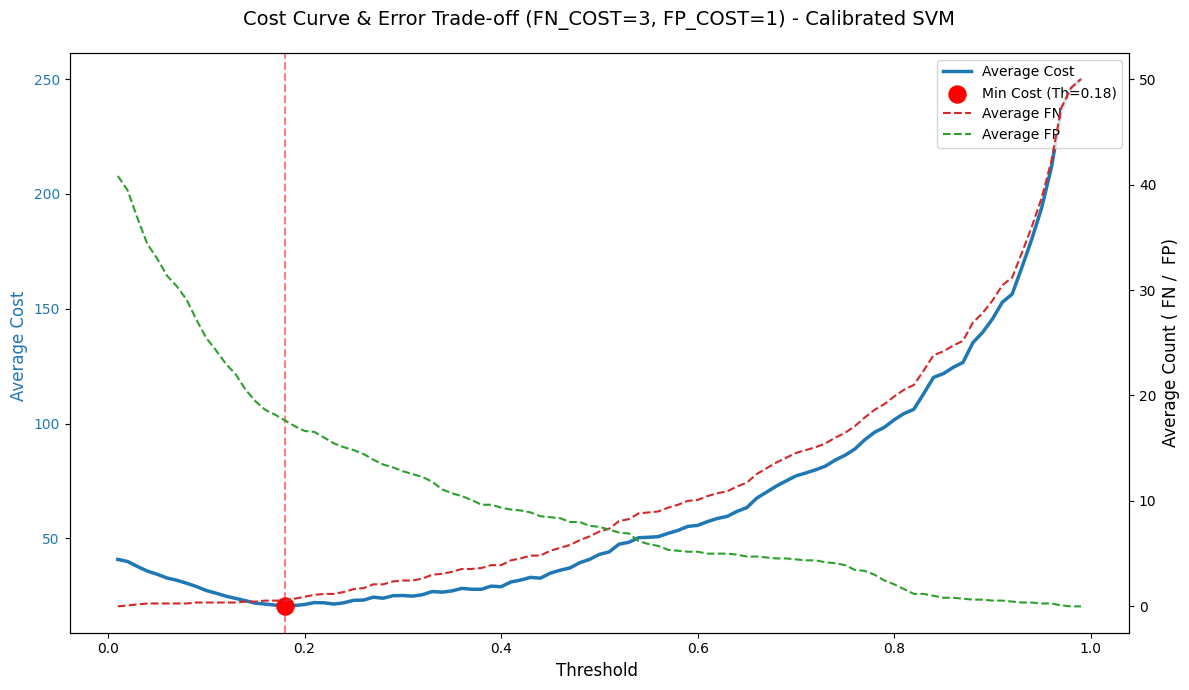

In [16]:

FN_COST = 5.0
FP_COST = 1.0

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

cost_matrix = []
fn_matrix = []
fp_matrix = []

random_states = [10, 20, 30, 40, 50, 60, 2, 100, 500, 1000, 27]

for rs in random_states:

    print(f"Processing Random State : {rs}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=rs
    )


    base_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=0.1,
            class_weight=None,
            gamma=0.01,
            random_state=42
        ))
    ])


    model = CalibratedClassifierCV(base_pipeline, method='sigmoid', cv=3)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


    oof_prob = cross_val_predict(
        model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1
    )[:, 1]


    best_threshold = None
    best_cost = np.inf

    for th in thresholds:
        pred = (oof_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
        cost = FN_COST * fn + FP_COST * fp

        if cost < best_cost:
            best_cost = cost
            best_threshold = th

    # --------------------------------------------------
    # Final Model & Test Evaluation
    # --------------------------------------------------
    model.fit(X_train, y_train)

    test_prob = model.predict_proba(X_test)[:, 1]


    row_costs = []
    row_fns = []
    row_fps = []

    for th in thresholds:
        test_pred = (test_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()

        row_costs.append(FN_COST * fn + FP_COST * fp)
        row_fns.append(fn)
        row_fps.append(fp)

    cost_matrix.append(row_costs)
    fn_matrix.append(row_fns)
    fp_matrix.append(row_fps)


    test_pred_best = (test_prob >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, test_pred_best, labels=[0, 1]).ravel()
    test_cost = FN_COST * fn + FP_COST * fp
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results.append({
        "random_state": rs,
        "threshold": best_threshold,
        "cost_test": test_cost,
        "FN_test": fn,
        "FP_test": fp,
        "Recall_test": round(recall, 3)
    })


results = pd.DataFrame(results)
print("\n" + "="*70)
print("Results Table (With Calibration)\n")
print(results)
print("\nAverage Threshold:", results["threshold"].mean())
print("Average Recall:", results["Recall_test"].mean())
print("Average FN / FP:\n", results[["FN_test", "FP_test"]].mean())


avg_costs = np.mean(cost_matrix, axis=0)
avg_fns = np.mean(fn_matrix, axis=0)
avg_fps = np.mean(fp_matrix, axis=0)

min_cost_idx = np.argmin(avg_costs)
min_cost_threshold = thresholds[min_cost_idx]
min_cost_value = avg_costs[min_cost_idx]

fig, ax1 = plt.subplots(figsize=(12, 7))

color = 'tab:blue'
ax1.set_xlabel('Threshold ', fontsize=12)
ax1.set_ylabel('Average Cost ', color=color, fontsize=12)
ax1.plot(thresholds, avg_costs, color=color, linewidth=2.5, label='Average Cost')
ax1.tick_params(axis='y', labelcolor=color)
ax1.scatter(min_cost_threshold, min_cost_value, color='red', s=150, zorder=5, label=f'Min Cost (Th={min_cost_threshold:.2f})')
ax1.axvline(x=min_cost_threshold, color='red', linestyle='--', alpha=0.5)


ax2 = ax1.twinx()
color_fn = 'tab:red'
color_fp = 'tab:green'
ax2.set_ylabel('Average Count ( FN /  FP)', fontsize=12)
ax2.plot(thresholds, avg_fns, color=color_fn, linestyle='--', label='Average FN')
ax2.plot(thresholds, avg_fps, color=color_fp, linestyle='--', label='Average FP')
ax2.tick_params(axis='y')

plt.title('Cost Curve & Error Trade-off (FN_COST=5, FP_COST=1) - Calibrated SVM', fontsize=14, pad=20)
fig.tight_layout()


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

THE BEST AVERAGE THRESHOLD IS 0.18 FOR

 `SVC(
    kernel="rbf",
    C=0.1,
    class_weight=None,
    gamma=0.01,
    probability=True
)`

* Average Threshold: 0.24181818181818188
* Average Recall: 0.9690909090909091
*
Average FN / FP:
* FN_test     1.545455
* FP_test    15.363636


# Final Model Evaluation

Evaluate the optimized model on the test dataset using several performance metrics.

Metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- SHAP

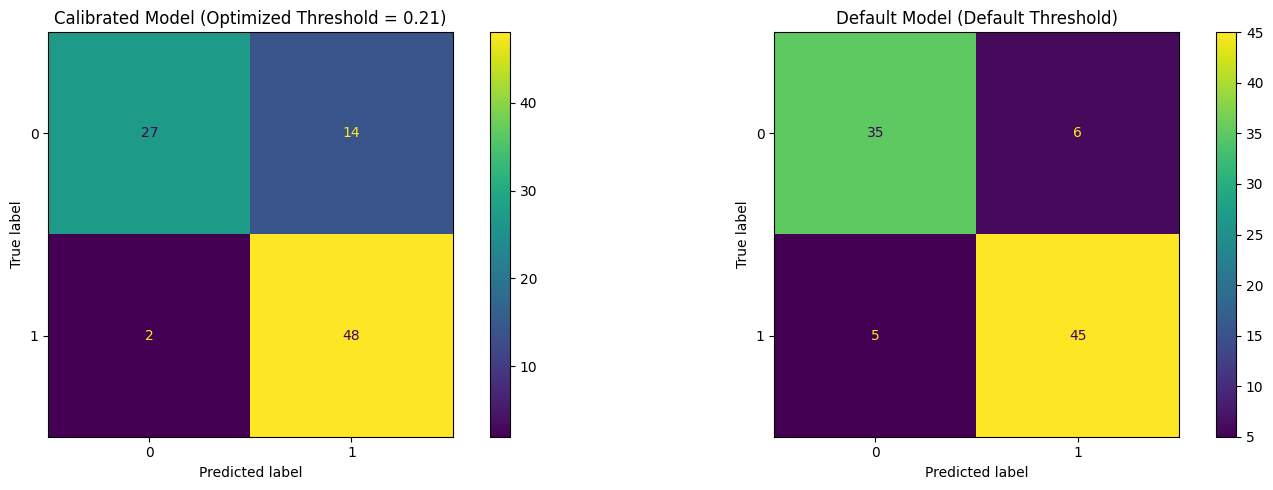

In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=40
)


base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=0.1, gamma=0.01, class_weight=None, random_state=42))
])

# Calibrated model
calibrated_model = CalibratedClassifierCV(base_pipeline, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

probs_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

#  Default model
default_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=0.1, gamma=0.01, class_weight=None, random_state=42,probability=True))
])
default_model.fit(X_train, y_train)
pred_default = default_model.predict(X_test)


threshold = 0.21
y_pred_custom = (probs_calibrated >= threshold).astype(int)


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, ax=ax[0])
ax[0].set_title(f"Calibrated Model (Optimized Threshold = {threshold})")

ConfusionMatrixDisplay.from_predictions(y_test, pred_default, ax=ax[1])
ax[1].set_title("Default Model (Default Threshold)")

plt.tight_layout()
plt.show()

auc_score : 0.937560975609756


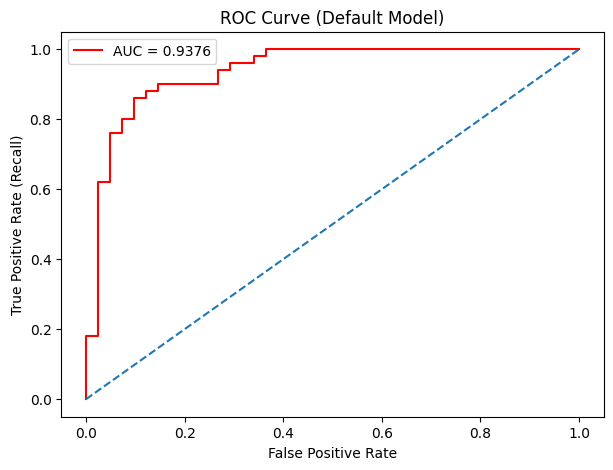

[       inf 0.98156714 0.9378955  0.93427251 0.77377372 0.76511217
 0.62492601 0.61444664 0.53766678 0.452668   0.3786236  0.37576065
 0.36795955 0.3407695  0.31639399 0.19152908 0.16950335 0.16756014
 0.16099487 0.12379148 0.11423597 0.10631122 0.10134622 0.0068646 ]


In [27]:
from sklearn.metrics import roc_auc_score, roc_curve

test_prob = default_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_prob)

auc_score = roc_auc_score(y_test, test_prob)
print(f"auc_score : {auc_score}")
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}", color="r")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Default Model)")
plt.legend()
plt.show()
print(thresholds)

In [19]:
from sklearn.metrics import classification_report
print(f"Default Threshold (0.31) :\n{classification_report(y_test , pred_default)}\n==================================================================")
print(f"Optimized Threshold ({threshold}) :\n{classification_report(y_test , y_pred_custom)}")

Default Threshold (0.31) :
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        41
           1       0.88      0.90      0.89        50

    accuracy                           0.88        91
   macro avg       0.88      0.88      0.88        91
weighted avg       0.88      0.88      0.88        91

Optimized Threshold (0.21) :
              precision    recall  f1-score   support

           0       0.93      0.66      0.77        41
           1       0.77      0.96      0.86        50

    accuracy                           0.82        91
   macro avg       0.85      0.81      0.81        91
weighted avg       0.84      0.82      0.82        91



# Model Explainability (SHAP)

SHAP (SHapley Additive exPlanations) is used to explain individual predictions and identify the contribution of each feature to the model's decisions.

F:\PY\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values... (This might take a minute)


100%|██████████| 50/50 [09:13<00:00, 11.08s/it]

Plotting SHAP Beeswarm Plot...


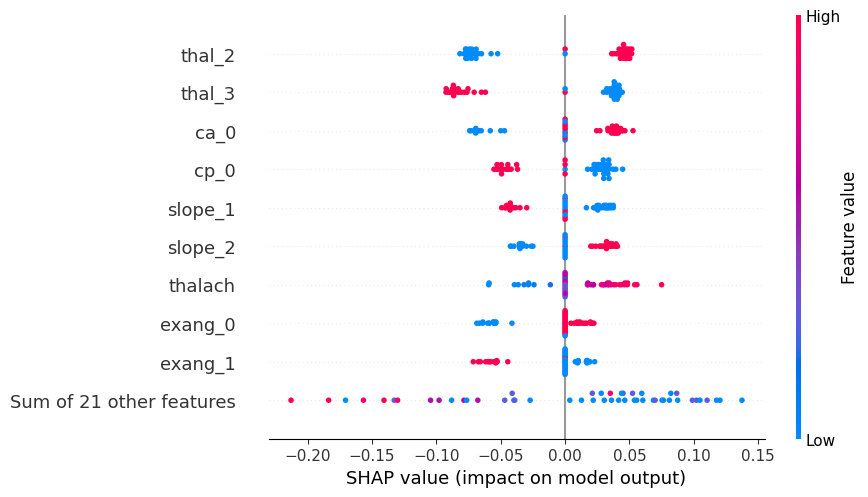

Plotting SHAP Bar Plot...


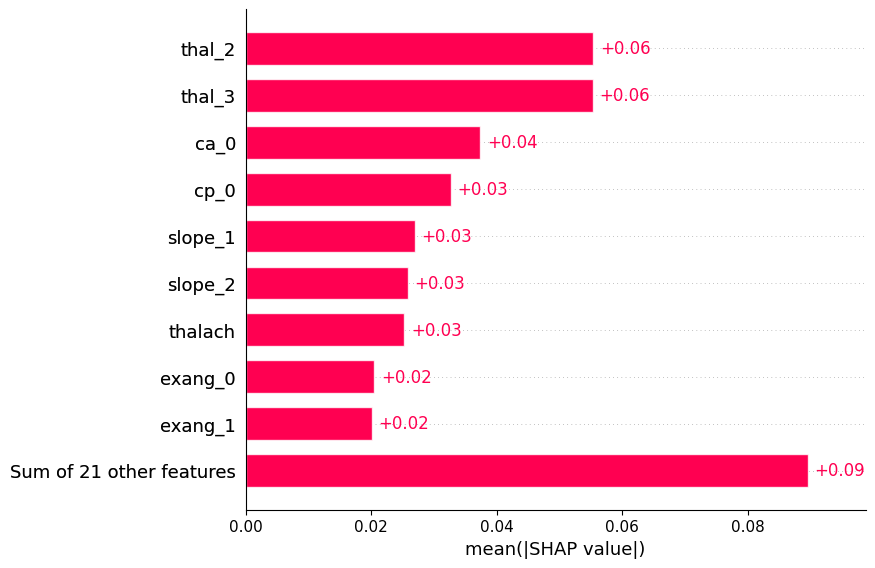

In [20]:
import shap

raw_feature_names = ['One_Hot_Encoder__sex_0', 'One_Hot_Encoder__sex_1', 'One_Hot_Encoder__cp_0',
                     'One_Hot_Encoder__cp_1', 'One_Hot_Encoder__cp_2', 'One_Hot_Encoder__cp_3',
                     'One_Hot_Encoder__fbs_0', 'One_Hot_Encoder__fbs_1', 'One_Hot_Encoder__restecg_0',
                     'One_Hot_Encoder__restecg_1', 'One_Hot_Encoder__restecg_2', 'One_Hot_Encoder__exang_0',
                     'One_Hot_Encoder__exang_1', 'One_Hot_Encoder__slope_0', 'One_Hot_Encoder__slope_1',
                     'One_Hot_Encoder__slope_2', 'One_Hot_Encoder__ca_0', 'One_Hot_Encoder__ca_1',
                     'One_Hot_Encoder__ca_2', 'One_Hot_Encoder__ca_3', 'One_Hot_Encoder__ca_4',
                     'One_Hot_Encoder__thal_0', 'One_Hot_Encoder__thal_1', 'One_Hot_Encoder__thal_2',
                     'One_Hot_Encoder__thal_3', 'remainder__age', 'remainder__trestbps', 'remainder__chol',
                     'remainder__thalach', 'remainder__oldpeak']

feature_names = [name.replace('One_Hot_Encoder__', '').replace('remainder__', '') for name in raw_feature_names]

print("Calculating SHAP values... (This might take a minute)")




X_train_sample = shap.sample(X_train, 50,random_state=42)
explainer = shap.KernelExplainer(calibrated_model.predict_proba, X_train_sample)

np.random.seed(42)
X_test_sample = X_test[:50]
shap_values = explainer.shap_values(X_test_sample)


if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1]

explanation = shap.Explanation(
    values=sv,
    base_values=explainer.expected_value[1],
    data=X_test_sample,
    feature_names=feature_names
)


print("Plotting SHAP Beeswarm Plot...")
shap.plots.beeswarm(explanation)

print("Plotting SHAP Bar Plot...")
shap.plots.bar(explanation)

🔍 Model Interpretability with SHAP (SHapley Additive exPlanations)
In medical diagnosis, a model must not only be accurate but also interpretable. We use SHAP to peek inside the "black box" and understand why the model makes specific predictions, ensuring it aligns with clinical logic rather than spurious correlations.

⚠️ Important Note on One-Hot Encoding
Because categorical features (like cp, thal, slope) were One-Hot Encoded, their overall importance is fragmented across multiple binary columns (e.g., thal_2, thal_3). This is why the "Sum of 21 other features" bar is tall—the cumulative effect of these split features is massive, even if individual dummy columns appear smaller.

📊 How to Read the SHAP Plots
1. Beeswarm Plot (Feature Importance & Direction)

Y-Axis: Features ranked by importance (top = most important).
X-Axis (SHAP Value): Impact on the model's output.
Right side (Positive values): Pushes the prediction towards Class 1 (Heart Disease).
Left side (Negative values): Pushes the prediction towards Class 0 (Healthy).
Color: Feature value.
Red: High value (or "1" / Has the condition for OHE features).
Blue: Low value (or "0" / Does not have the condition).
2. Bar Plot (Mean Absolute Impact)Shows the average magnitude of each feature's impact across all predictions, regardless of direction.

🩺 Clinical Insights Extracted
The SHAP analysis confirms our model has learned clinically valid patterns:

High-Risk Indicators: Having specific defects like thal_2  (red dots on the right) significantly increases the model's prediction of heart disease.
Protective Indicators: Notice ca_0 (0 major vessels colored/blocked). Red dots (patients who have 0 blockages) fall on the left (negative) side, meaning this feature pushes the model strongly towards a Healthy prediction. This perfectly aligns with medical knowledge.

# Conclusion

Among all evaluated machine learning algorithms, the selected model achieved the best balance between predictive performance and medical safety.

Special attention was given to reducing False Negatives through threshold optimization, making the final model more suitable for heart disease risk prediction.